In [22]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import scipy.sparse

In [23]:
y_train = np.load('./data/y_train.npy')
y_test = np.load('./data/y_test.npy')

X_train = scipy.sparse.load_npz('./data/X_train.npz')
X_test = scipy.sparse.load_npz('./data/X_test.npz', )

### Train-validation split

In [24]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2)

In [25]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape

((150316, 5000), (150316,), (37580, 5000), (37580,))

## Multinomial Logistic Regression with Regularization

In [26]:
from sklearn.linear_model import LogisticRegression

Set up a vector of $\lambda$ (taken from Introduction to Statistical Learning)

In [27]:
lam_max = np.abs(X_train.T * (y_train - y_train.mean())).max()
lam_val = lam_max * np.exp(np.linspace(np.log(1e-6), np.log(1), 50))

`LogisticRegression()` will default to multinomial. `liblinear` is a recommended solver for sparse matrix format. Note: $\lambda$ is input as inverse.

In [28]:
logit = LogisticRegression(penalty='l1', C=1/lam_max, solver='liblinear', warm_start=True, fit_intercept=True, max_iter=1000)

In [ ]:
# ~40s to run

accuracy = []
accuracy_val = []

for lam in lam_val:
    logit.C = 1/lam
    logit.fit(X_train, y_train)
    y_pred = logit.predict(X_train)
    y_pred_val = logit.predict(X_val)
    accuracy.append(np.mean(y_train == y_pred))
    accuracy_val.append(np.mean(y_val == y_pred_val))

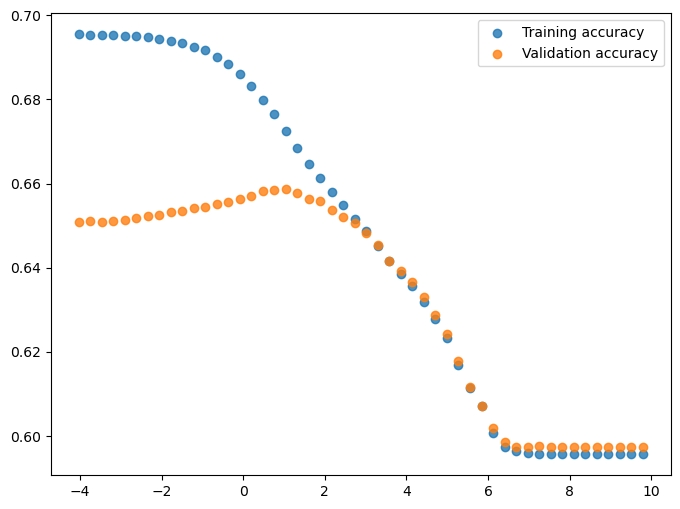

In [30]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(8,6))
plt.scatter(np.log(lam_val), accuracy, alpha=0.8, label='Training accuracy')
plt.scatter(np.log(lam_val), accuracy_val, alpha=0.8, label='Validation accuracy')
plt.legend()
plt.show()

Best $\lambda$ from validation dataset:

In [31]:
lam_val[ int(np.argmax(accuracy_val)) ]

np.float64(2.8509834719285627)

In [32]:
logit = LogisticRegression(penalty='l1', C=1/1.639140565962462, solver='liblinear', warm_start=True, fit_intercept=True, max_iter=1000)

In [33]:
logit.fit(X_train, y_train)

LogisticRegression(C=0.6100758048244783, max_iter=1000, penalty='l1',
                   solver='liblinear', warm_start=True)

### Final prediction accuracy

In [34]:
y_pred_test = logit.predict(X_test)
np.mean(y_pred_test == y_test)

np.float64(0.6569451836083023)